# Tải dữ liệu

In [504]:
# !kaggle datasets download -d furcifer/fane-facial-expressions-and-emotion-dataset -p ./Dts/ --unzip

# Chuẩn bị môi trường và nạp dữ liệu

In [505]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split


train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
print(train.shape)
print(test.shape)
train.head()

(8693, 14)
(4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


# Khám phá dữ liệu

In [506]:
print(train.dtypes)
train["Destination"].value_counts()

PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Name             object
Transported        bool
dtype: object


,count
Destination,
TRAPPIST-1e,5915
55 Cancri e,1800
PSO J318.5-22,796


Xoá cột tên đi :)) chắc là ko có ai thiên vị về tên đâu

In [507]:
train = train.drop(columns=["Name"])
test = test.drop(columns=["Name"])


In [508]:
train["Cabin"].value_counts()
print(train.dtypes)

PassengerId      object
HomePlanet       object
CryoSleep        object
Cabin            object
Destination      object
Age             float64
VIP              object
RoomService     float64
FoodCourt       float64
ShoppingMall    float64
Spa             float64
VRDeck          float64
Transported        bool
dtype: object


Cabin quá nhiều loại, mỗi loại bao gồm 3 thành phần (deck/num/side) => tách làm 3 cột dữ liệu

CryoSleep và VIP có giá trị là True/False mà có dạng là object nên đổi thành bool

# Xử lí dữ liệu

PassengerId     0.000000
HomePlanet      2.312205
CryoSleep       2.496261
Cabin           2.289198
Destination     2.093639
Age             2.059128
VIP             2.335212
RoomService     2.082135
FoodCourt       2.105142
ShoppingMall    2.392730
Spa             2.105142
VRDeck          2.162660
Transported     0.000000
dtype: float64


<Axes: xlabel='Transported', ylabel='count'>

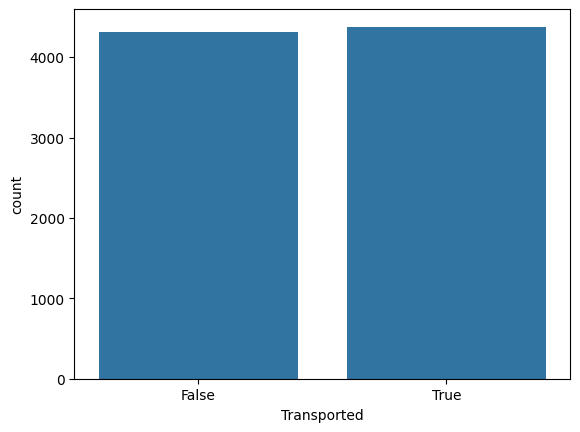

In [509]:
print(train.isnull().mean() * 100)
for col in ["CryoSleep", "VIP"]:
    X_test_kaggle[col] = X_test_kaggle[col].astype(bool)
    X_test[col] = X_test[col].astype(bool)

sb.countplot(x="Transported", data=train)


Dữ liệu bị null khá ít => Miền median với biến số, điền mode với biến phân loại

Dữ đầu vào khá cân bằng (gần như là tỉ lệ 50:50)

# Tách dữ liệu

In [510]:
# Tách Cabin

train[["Deck", "Num", "Side"]] = train["Cabin"].str.split("/", expand=True)
test[["Deck", "Num", "Side"]] = test["Cabin"].str.split("/", expand=True)

# Chuyển CabinNum sang số
train["Num"] = pd.to_numeric(train["Num"], errors="coerce")
test["Num"] = pd.to_numeric(test["Num"], errors="coerce")

# Drop cột
X = train.drop(columns=["Transported","PassengerId"])
X_test_kaggle = test.drop(columns=["PassengerId"])

split_col = ["Destination","HomePlanet","Deck", "Side"]
# Tách cột
X = pd.get_dummies(X, columns=split_col, drop_first=False)
X_test_kaggle = pd.get_dummies(X_test_kaggle, columns=split_col, drop_first=False)

# Xoá cột trong split_col
X = X.drop(columns=["Cabin"])
X_test_kaggle = X_test_kaggle.drop(columns=["Cabin"])
y = train["Transported"].astype(int)

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify= y,
    random_state=36
)

result = {}

In [511]:
# Cột số
num_train = train.select_dtypes(include=["int64", "float64"]).columns
num_test = test.select_dtypes(include=["int64", "float64"]).columns

train[num_train] = train[num_train].fillna(train[num_train].median())
test[num_test] = test[num_test].fillna(train[num_train].median())  # dùng median của train

# Cột categorical
cate_train = train.select_dtypes(include=["object", "bool"]).columns
cate_test = test.select_dtypes(include=["object", "bool"]).columns

for col in cate_train:
    train[col] = train[col].fillna(train[col].mode()[0])

for col in cate_test:
    test[col] = test[col].fillna(train[col].mode()[0])  # dùng mode của train

for col in ["CryoSleep", "VIP"]:
    X_test_kaggle[col] = X_test_kaggle[col].astype(bool)
    X_test[col] = X_test[col].astype(bool)
    X_train[col] = X_train[col].astype(bool)      # ← THÊM DÒNG NÀY

/tmp/ipykernel_18207/3354295250.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train[col] = train[col].fillna(train[col].mode()[0])
/tmp/ipykernel_18207/3354295250.py:16: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  test[col] = test[col].fillna(train[col].mode()[0])  # dùng mode của train


# Bagging

In [503]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=36,
)

rf.fit(X_train, y_train)

rf_pred_kaggle = rf.predict(X_test_kaggle)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

# Boosting

In [512]:

xgb = XGBClassifier(
    n_estimators=600, #Số cây
    learning_rate=0.05, #Tốc độ học
    max_depth=20, #Độ sâu mỗi cây
    subsample=0.8, # %dòng sẽ lấy
    colsample_bytree=0.8, # % cột sẽ lấy
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train, y_train)

xgb_pred_kaggle = xgb.predict(X_test_kaggle)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test,xgb_pred)

# Stacking

In [ ]:
estimators = [
    ("rf", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )),
    ("xgb", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    ))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stack.fit(X_train, y_train)

stack_pred_kaggle = stack.predict(X_test_kaggle)

stack_pred = stack.predict(X_test)

stack_acc = accuracy_score(y_test, stack_pred)


# Báo cáo benchmark

In [ ]:
models = {
    "Bagging": rf_acc,
    "Boosting": xgb_acc,
    "Stacking": stack_acc
}

results = {}

for name, acc in models.items():
    results[name] = acc

pd.DataFrame(results.items(), columns=["Method", "Accuracy"])

# Xuất dữ liệu predict qua file csv để nộp

In [ ]:
stack_pred_kaggle =  stack_pred_kaggle.astype(bool)
sub =  pd.DataFrame(
    {
        "PassengerId": test["PassengerId"].astype(str),
        "Transported": stack_pred_kaggle
    }
)
sub.to_csv("submission_rf.csv", index=False)